# 03 - MODÉLISATION

## Plan d'expérience

1. Charger les données prétraitées
2. Tester plusieurs modèles (baseline, régression, boosting, ensemble)
3. Évaluer sur validation set
4. Sélectionner le meilleur modèle
5. Prédire sur test et soumettre

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import warnings
warnings.filterwarnings('ignore')

print("Imports réussis")


Imports réussis


In [2]:
def rmspe(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mask = y_true > 0
    return np.sqrt(np.mean(((y_true[mask] - y_pred[mask]) / y_true[mask])**2))

### Charger les données prétraitées depuis les fichiers sauvegardés

In [3]:


data_path = '../data/processed/'

# Charger train et validation
X_train = pd.read_csv(data_path + 'X_train.csv')
y_train = pd.read_csv(data_path + 'y_train.csv').squeeze()

X_val = pd.read_csv(data_path + 'X_val.csv')
y_val = pd.read_csv(data_path + 'y_val.csv').squeeze()

# Charger test
X_test = pd.read_csv(data_path + 'X_test.csv')

print(f" Données chargées:")
print(f"  X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"  X_val:   {X_val.shape},   y_val:   {y_val.shape}")
print(f"  X_test:  {X_test.shape}")
print(f"\nPremières colonnes: {list(X_train.columns[:10])}")

 Données chargées:
  X_train: (802942, 125), y_train: (802942,)
  X_val:   (41396, 125),   y_val:   (41396,)
  X_test:  (41088, 125)

Premières colonnes: ['Store', 'DayOfWeek', 'Promo', 'SchoolHoliday', 'StateHoliday_flag', 'CompetitionDistance', 'Promo2', 'Year', 'Month', 'Promo2_active']


In [4]:
# vérifier la structure de X_test pour comprendre l'index
print("X_test.index.unique()\n", X_test.index.unique()[:10])
print("X_test.reset_index().head()")
print(X_test.reset_index().head())

X_test.index.unique()
 RangeIndex(start=0, stop=10, step=1)
X_test.reset_index().head()
   index  Store  DayOfWeek  Promo  SchoolHoliday  StateHoliday_flag  \
0      0      1          6      0              1                  0   
1      1      1          7      0              1                  0   
2      2      1          1      1              1                  0   
3      3      1          2      1              1                  0   
4      4      1          3      1              1                  0   

   CompetitionDistance  Promo2  Year  Month  ...  DayOfWeek_StoreType_4_b  \
0               1270.0       0  2015      8  ...                    False   
1               1270.0       0  2015      8  ...                    False   
2               1270.0       0  2015      8  ...                    False   
3               1270.0       0  2015      8  ...                    False   
4               1270.0       0  2015      8  ...                    False   

   DayOfWeek_StoreType

### Vérifier et gérer les NaN 
### Modèles de baseline

In [5]:
print("📊 Vérification des valeurs manquantes:")
print(f"NaN dans X_train: {X_train.isna().sum().sum()}")
print(f"NaN dans X_val: {X_val.isna().sum().sum()}")
print(f"NaN dans X_test: {X_test.isna().sum().sum()}")

# (Optionnel mais safe) imputer uniquement si NaN et uniquement les colonnes numériques
if X_train.isna().sum().sum() > 0:
    print("\n⚠️ Colonnes avec des NaN (train):")
    nan_cols = X_train.isna().sum()
    print(nan_cols[nan_cols > 0])

    from sklearn.impute import SimpleImputer

    num_cols = X_train.select_dtypes(include=[np.number]).columns
    imputer = SimpleImputer(strategy="median")

    X_train[num_cols] = imputer.fit_transform(X_train[num_cols])
    X_val[num_cols]   = imputer.transform(X_val[num_cols])
    X_test[num_cols]  = imputer.transform(X_test[num_cols])

    print("✅ NaN imputés")
    print(f"NaN après imputation dans X_train: {X_train.isna().sum().sum()}")

# -----------------------------
#  Modèles de baseline
# -----------------------------
results = {}

print("\n" + "="*50)
print("1️⃣ Ridge Regression (baseline)")
print("="*50)

from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

y_val_pred = ridge.predict(X_val)

# ✅ Kaggle score = RMSPE sur Sales (échelle originale)
y_val_true_sales = np.expm1(y_val)
y_val_pred_sales = np.expm1(y_val_pred)

ridge_rmspe = rmspe(y_val_true_sales, y_val_pred_sales)
results["Ridge"] = {"RMSPE": ridge_rmspe, "model": ridge}

print(f"  RMSPE: {ridge_rmspe:.5f}")

📊 Vérification des valeurs manquantes:
NaN dans X_train: 2075
NaN dans X_val: 111
NaN dans X_test: 0

⚠️ Colonnes avec des NaN (train):
CompetitionDistance    2075
dtype: int64
✅ NaN imputés
NaN après imputation dans X_train: 0

1️⃣ Ridge Regression (baseline)
  RMSPE: 0.40145


### Random Forest (robuste, captures non-linearité)

In [6]:
print("\n" + "="*50)
print("2️⃣ Random Forest")
print("="*50)

# y_val est en log1p -> convertir une seule fois
y_val_true_sales = np.expm1(y_val)

rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    max_depth=20,
    min_samples_leaf=2,
    max_features="sqrt"
)
rf.fit(X_train, y_train)

y_val_pred = rf.predict(X_val)
rf_rmspe = rmspe(y_val_true_sales, np.expm1(y_val_pred))

results["RandomForest"] = {"RMSPE": rf_rmspe, "model": rf}
print(f"RF RMSPE: {rf_rmspe:.5f}")

print("\n" + "="*50)
print("3️⃣ Gradient Boosting")
print("="*50)

gb = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)
gb.fit(X_train, y_train)

y_val_pred = gb.predict(X_val)
gb_rmspe = rmspe(y_val_true_sales, np.expm1(y_val_pred))

results["GradientBoosting"] = {"RMSPE": gb_rmspe, "model": gb}
print(f"GB RMSPE: {gb_rmspe:.5f}")


2️⃣ Random Forest
RF RMSPE: 0.26962

3️⃣ Gradient Boosting
GB RMSPE: 0.37756


In [7]:
import lightgbm as lgb
import numpy as np

print("\n" + "="*50)
print("4️⃣ LightGBM")
print("="*50)

# y_val sur l'échelle Sales pour RMSPE
y_val_true_sales = np.expm1(y_val)

lgbm = lgb.LGBMRegressor(
    n_estimators=5000,
    learning_rate=0.03,
    num_leaves=64,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    verbosity=-1,
    force_row_wise=True
)

lgbm.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric="l2",
    callbacks=[lgb.early_stopping(stopping_rounds=200, verbose=False)]
)

y_val_pred = lgbm.predict(X_val)
lgbm_rmspe = rmspe(y_val_true_sales, np.expm1(y_val_pred))

results["LightGBM"] = {"RMSPE": lgbm_rmspe, "model": lgbm}
print(f"LightGBM RMSPE: {lgbm_rmspe:.5f}")


4️⃣ LightGBM
LightGBM RMSPE: 0.13436


### Résumé des résultats

In [8]:
print("\n" + "="*70)
print("COMPARAISON DES MODÈLES")
print("="*70)

results_df = pd.DataFrame({
    model: {metric: value for metric, value in metrics.items() if metric != 'model'}
    for model, metrics in results.items()
}).T

print(results_df)

# Meilleur modèle selon RMSPE (plus petit = meilleur)
best_model_name = results_df['RMSPE'].idxmin()
best_model = results[best_model_name]['model']

print(f"\n🏆 Meilleur modèle (selon RMSPE): {best_model_name}")
print(f"   RMSPE = {results_df.loc[best_model_name, 'RMSPE']:.5f}")


COMPARAISON DES MODÈLES
                     RMSPE
Ridge             0.401447
RandomForest      0.269623
GradientBoosting  0.377563
LightGBM          0.134356

🏆 Meilleur modèle (selon RMSPE): LightGBM
   RMSPE = 0.13436


### Predictions sur test set avec le meilleur modèle

In [9]:
print("\n" + "="*70)
print("💾 PRÉDICTIONS SUR TEST SET")
print("="*70)

y_test_pred = best_model.predict(X_test)

# ✅ Lire Id/Open dans le même ordre que X_test (évite mismatch)
test_meta = pd.read_csv("../data/processed/test_meta.csv")
ids = test_meta["Id"]
open_col = test_meta["Open"].fillna(1)

# Inverse de log1p (retour à l'échelle Sales)
sales_pred = np.expm1(y_test_pred)

# Sécurité : pas de valeurs négatives
sales_pred = np.maximum(0, sales_pred)

# Règle Kaggle : si Open=0 => Sales=0 (Open peut être NaN -> on considère ouvert)
sales_pred = np.where(open_col == 0, 0, sales_pred)

submission = pd.DataFrame({
    "Id": ids,
    "Sales": sales_pred
})

submission_path = "../data/submission.csv"
submission.to_csv(submission_path, index=False)

print("✅ Soumission créée:")
print(f"   Chemin: {submission_path}")
print(f"   Shape: {submission.shape}")
print(f"   Aperçu:\n{submission.head()}")

print("\n📈 Statistiques des prédictions:")
print(f"   Min Sales: {submission['Sales'].min():.2f}")
print(f"   Max Sales: {submission['Sales'].max():.2f}")
print(f"   Moyenne:   {submission['Sales'].mean():.2f}")
print(f"   Médiane:   {submission['Sales'].median():.2f}")

print("\n🔎 Contrôle: Sales doit être 0 quand Open=0")
print("   Nb Open=0:", int((open_col == 0).sum()))
print("   Nb Sales>0 parmi Open=0:", int(((open_col == 0) & (submission['Sales'] > 0)).sum()))


💾 PRÉDICTIONS SUR TEST SET
✅ Soumission créée:
   Chemin: ../data/submission.csv
   Shape: (41088, 2)
   Aperçu:
      Id        Sales
0  40233  4066.795167
1  39377     0.000000
2  38521  5093.947698
3  37665  4826.597602
4  36809  4748.023944

📈 Statistiques des prédictions:
   Min Sales: 0.00
   Max Sales: 23950.26
   Moyenne:   5484.99
   Médiane:   5692.99

🔎 Contrôle: Sales doit être 0 quand Open=0
   Nb Open=0: 5984
   Nb Sales>0 parmi Open=0: 0



🎯 IMPORTANCE DES FEATURES (Top 15)
                          Feature  Importance
                            Store       61158
              CompetitionDistance       59962
                   CompetitionAge       36424
                        DayOfWeek       22349
                            Month       16007
                             Year       15101
                           Promo2        7813
                            Promo        7494
                    SchoolHoliday        6608
          DayOfWeek_StoreType_5_a        4843
CompetitionOpenSinceMonth_missing        4198
                     Assortment_a        3552
                    Promo2_active        2805
             Promo_Assortment_0_a        2360
             Promo_Assortment_0_c        2222


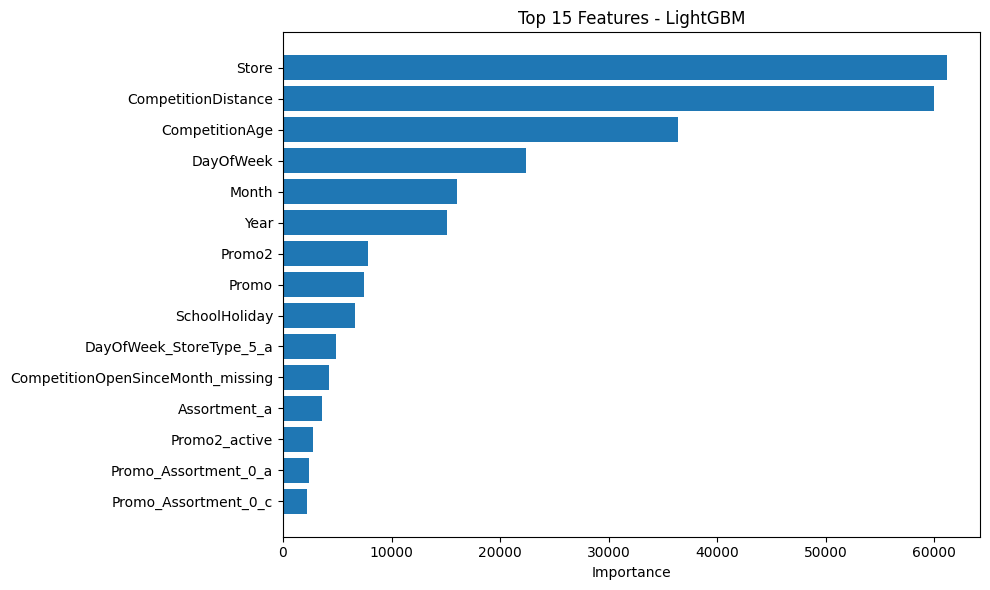

In [10]:
# 🎯 Analyse d'importance des features (si le modèle le supporte)

import matplotlib.pyplot as plt

print("\n" + "="*70)
print("🎯 IMPORTANCE DES FEATURES (Top 15)")
print("="*70)

if hasattr(best_model, "feature_importances_"):
    feature_importance = (
        pd.DataFrame({
            "Feature": X_train.columns,
            "Importance": best_model.feature_importances_
        })
        .sort_values("Importance", ascending=False)
        .head(15)
    )

    print(feature_importance.to_string(index=False))

    # Plot (plus lisible: le plus important en haut)
    plt.figure(figsize=(10, 6))
    plt.barh(feature_importance["Feature"][::-1], feature_importance["Importance"][::-1])
    plt.xlabel("Importance")
    plt.title(f"Top 15 Features - {best_model_name}")
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Le modèle sélectionné ne supporte pas l'analyse d'importance des features")